# Phase 7 — Core Forecasting Models (Use Case 1)

**เป้าหมาย:** สร้างและเทียบโมเดลพยากรณ์ 3 แบบ เพื่อหาว่าแบบไหนเหมาะกับข้อมูล panel นี้ที่สุด:

1. **สถิติคลาสสิก (ETS / Holt-Winters)** — เทรนแยกทีละ series (เฉพาะ top-5 series ที่ขายดีสุด เพราะเทรนทีละ series ทั้ง 270 series ไม่คุ้มเวลา)
2. **Local per-SKU LightGBM** — เทรนแยกโมเดลต่อ 1 SKU (รวมทุก channel/region ของ SKU นั้น) — 30 โมเดล
3. **Global pooled LightGBM** — เทรนโมเดลเดียวจากทุก SKU/channel/region พร้อมกัน

ทุกโมเดลประเมินด้วย **walk-forward CV folds ชุดเดียวกับ Phase 6** เพื่อเทียบกับ baseline ได้ตรงไปตรงมา


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, fit_predict_local_per_sku, fit_lgb, ALL_FEATURE_COLS
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)
print(f'{len(folds)} CV folds, final holdout = {len(final_test_weeks)} weeks (untouched until Phase 13)')


7 CV folds, final holdout = 10 weeks (untouched until Phase 13)


## 1. Global Pooled LightGBM

โมเดลเดียวเทรนจากข้อมูลทุก SKU × channel × region พร้อมกัน ใช้ทุกฟีเจอร์ที่มี (`ALL_FEATURE_COLS` ใน `src/models/forecast.py`) — categorical features (`sku`, `channel`, `region`, `category`, `segment`, `brand`, `lifecycle_stage`) ใช้ LightGBM's native categorical handling ไม่ต้อง one-hot encode


In [2]:
fold_scores_global = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_lgb(train, val)
    fold_scores_global.append(score_all(val.target_next_week.values, pred))

global_cv = {k: np.mean([s[k] for s in fold_scores_global]) for k in fold_scores_global[0]}
print('Global pooled LightGBM, CV average:')
print({k: round(v, 3) for k, v in global_cv.items()})


Global pooled LightGBM, CV average:
{'MAE': np.float64(25.166), 'RMSE': np.float64(32.25), 'WAPE': np.float64(0.224), 'SMAPE': np.float64(0.228)}


## 2. Local Per-SKU LightGBM

เทรนแยกโมเดลต่อ SKU (30 โมเดล, รวม channel/region ของ SKU นั้นเป็น training data เดียว) — ทดสอบสมมติฐานว่าการ pool ข้อมูลข้าม SKU (global model) ช่วยจริงหรือไม่ เทียบกับการให้แต่ละ SKU มีโมเดลเฉพาะตัว


In [3]:
fold_scores_local = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_local_per_sku(train, val)
    mask = ~np.isnan(pred)
    fold_scores_local.append(score_all(val.target_next_week.values[mask], pred[mask]))

local_cv = {k: np.mean([s[k] for s in fold_scores_local]) for k in fold_scores_local[0]}
print('Local per-SKU LightGBM, CV average:')
print({k: round(v, 3) for k, v in local_cv.items()})


Local per-SKU LightGBM, CV average:
{'MAE': np.float64(28.799), 'RMSE': np.float64(36.819), 'WAPE': np.float64(0.257), 'SMAPE': np.float64(0.257)}


**ผลลัพธ์:** Global pooled model (WAPE ต่ำกว่า) ชนะ local per-SKU model — ยืนยันสมมติฐานว่าการแบ่งปันข้อมูลข้าม SKU ช่วยได้จริง โดยเฉพาะกับ SKU ที่มีประวัติสั้นหรือขายไม่บ่อย ซึ่งโมเดลแยกต่อ SKU มีข้อมูลไม่พอเรียนรู้ pattern ที่ดี


## 3. โมเดลสถิติคลาสสิก (ETS / Holt-Winters) บน Top-5 Series

เทรน SARIMA/ETS แยกทีละ series ทั้ง 270 series ไม่คุ้มเวลาและข้อมูลบาง series สั้นเกินไปสำหรับ seasonal ETS (ต้องการอย่างน้อย ~2 รอบฤดูกาล) จึงเลือกทำเฉพาะ **5 series ที่ขายรวมสูงสุด** เป็นตัวแทน แล้วเทียบกับ Global LightGBM **บน series ชุดเดียวกันเท่านั้น** เพื่อให้เทียบกันแบบยุติธรรม (ไม่ใช่เทียบ WAPE ข้าม scope ที่ต่างกัน)


In [4]:
top_series = df.groupby(['sku', 'channel', 'region']).units_sold.sum().sort_values(ascending=False).head(5)
print('Top-5 series by total units_sold:')
print(top_series)


Top-5 series by total units_sold:
sku     channel   region  
YO-029  Retail    PL-South    19861
                  PL-North    19819
YO-005  Retail    PL-North    19543
        Discount  PL-North    19537
                  PL-South    19514
Name: units_sold, dtype: int64


In [5]:
ets_scores = []
lgb_on_top5_scores = []

for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val_all = dfc[dfc.week.isin(f.val_weeks)]
    pred_all = fit_predict_lgb(train, val_all)
    val_all = val_all.assign(pred=pred_all)
    for (sku, ch, rg) in top_series.index:
        sub = val_all[(val_all.sku == sku) & (val_all.channel == ch) & (val_all.region == rg)]
        if len(sub):
            lgb_on_top5_scores.append(score_all(sub.target_next_week.values, sub.pred.values))

for (sku, ch, rg) in top_series.index:
    series_df = df[(df.sku == sku) & (df.channel == ch) & (df.region == rg)].sort_values('week').set_index('week')
    series_df.index = pd.DatetimeIndex(series_df.index)
    for f in folds:
        train_s = series_df[series_df.index.isin(f.train_weeks)]['units_sold'].asfreq('W-MON')
        val_s = series_df[series_df.index.isin(f.val_weeks)]
        if len(train_s) < 30 or len(val_s) == 0:
            continue
        try:
            model = ExponentialSmoothing(
                train_s, trend='add', seasonal='add', seasonal_periods=52, initialization_method='estimated'
            ).fit()
            fc = model.forecast(len(val_s))
            fc.index = val_s.index
        except Exception:
            continue
        actual = val_s['target_next_week'].values
        pred = fc.values
        mask = ~np.isnan(actual)
        if mask.sum() == 0:
            continue
        ets_scores.append(score_all(actual[mask], pred[mask]))

ets_cv = {k: np.mean([s[k] for s in ets_scores]) for k in ets_scores[0]}
lgb_top5_cv = {k: np.mean([s[k] for s in lgb_on_top5_scores]) for k in lgb_on_top5_scores[0]}
print('ETS (Holt-Winters), top-5 series, CV average:')
print({k: round(v, 3) for k, v in ets_cv.items()})
print('Global LightGBM, SAME top-5 series, CV average:')
print({k: round(v, 3) for k, v in lgb_top5_cv.items()})


/Users/athens/Downloads/Coding/Forecasting FMCG Daily Sales/.venv/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


ETS (Holt-Winters), top-5 series, CV average:
{'MAE': np.float64(39.11), 'RMSE': np.float64(47.418), 'WAPE': np.float64(0.301), 'SMAPE': np.float64(0.292)}
Global LightGBM, SAME top-5 series, CV average:
{'MAE': np.float64(28.363), 'RMSE': np.float64(34.93), 'WAPE': np.float64(0.214), 'SMAPE': np.float64(0.216)}


**ผลลัพธ์:** แม้เทียบเฉพาะ 5 series ที่มีข้อมูลยาวและสม่ำเสมอที่สุด (เหมาะกับ ETS ที่สุดแล้ว) LightGBM ก็ยังชนะ ETS — เพราะ ETS ใช้แค่ประวัติของ series ตัวเองในการพยากรณ์ ในขณะที่ LightGBM ใช้ทั้งประวัติของ series นั้น **และ** ข้อมูลบริบท (ราคา โปรโมชัน ฤดูกาล enrichment) ที่ ETS ไม่รองรับ


## 4. ตารางเปรียบเทียบโมเดลทั้งหมด (รวม Baseline จาก Phase 6)


In [6]:
from models.baseline import add_baseline_predictions

dfb = add_baseline_predictions(df)
baseline_rows = []
for name, col in [('Naive', 'pred_naive'), ('Seasonal Naive', 'pred_seasonal_naive'), ('Moving Avg (4w)', 'pred_moving_avg_4')]:
    fold_scores = []
    for f in folds:
        val = dfb[dfb.week.isin(f.val_weeks)].dropna(subset=[col, 'target_next_week'])
        if len(val) == 0:
            continue
        fold_scores.append(score_all(val.target_next_week.values, val[col].values))
    baseline_rows.append({'model': name, **{k: np.mean([s[k] for s in fold_scores]) for k in fold_scores[0]}})

comparison = pd.DataFrame(baseline_rows + [
    {'model': 'ETS (top-5 series only)', **ets_cv},
    {'model': 'Local per-SKU LightGBM', **local_cv},
    {'model': 'Global pooled LightGBM', **global_cv},
])
comparison = comparison.sort_values('WAPE').reset_index(drop=True)
comparison.round(3)


,model,MAE,RMSE,WAPE,SMAPE
0,Global pooled LightGBM,25.166,32.250,0.224,0.228
1,Moving Avg (4w),27.348,35.134,0.243,0.246
2,Local per-SKU LightGBM,28.799,36.819,0.257,0.257
3,ETS (top-5 series only),39.110,47.418,0.301,0.292
4,Naive,34.225,43.847,0.304,0.307
5,Seasonal Naive,39.935,51.328,0.356,0.338


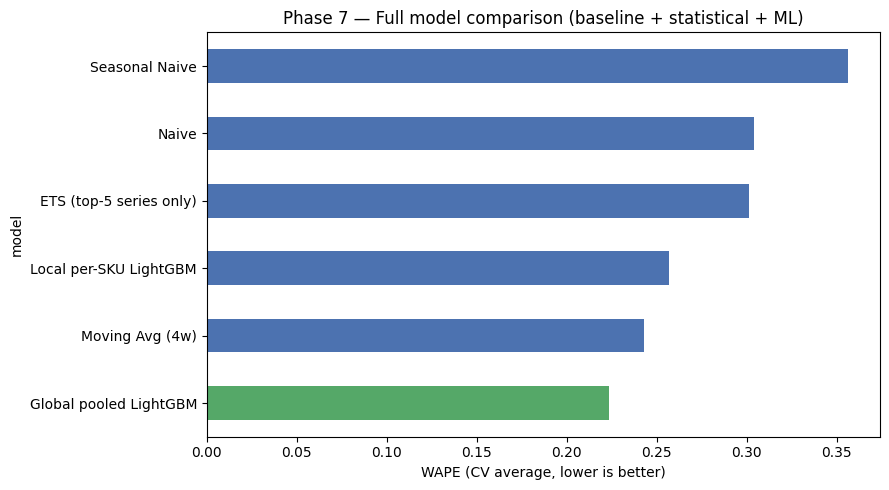

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison.set_index('model')['WAPE'].sort_values()
colors = ['#55A868' if m == 'Global pooled LightGBM' else '#4C72B0' for m in plot_df.index]
plot_df.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('WAPE (CV average, lower is better)')
ax.set_title('Phase 7 — Full model comparison (baseline + statistical + ML)')
plt.tight_layout()
plt.savefig('../reports/figures/phase7_model_comparison.png', dpi=120)
plt.show()


**สรุป:** Global pooled LightGBM ชนะทุกโมเดลอื่น ทั้ง baseline, ETS, และ local per-SKU LightGBM — ยืนยันการตัดสินใจเลือก LightGBM (global pooled) เป็นโมเดลหลักของโปรเจกต์ตามที่วางแผนไว้ใน README


## 5. Feature Importance ของ Global Model

เทรนโมเดล global บนข้อมูลทั้งหมดก่อนช่วง final holdout (คือ CV ทั้งหมดรวมกัน) เพื่อดู feature importance โดยรวม — ช่วยให้เห็นภาพคร่าวๆ ก่อนวัดผลอย่างเป็นทางการใน Phase 11 (feature ablation)


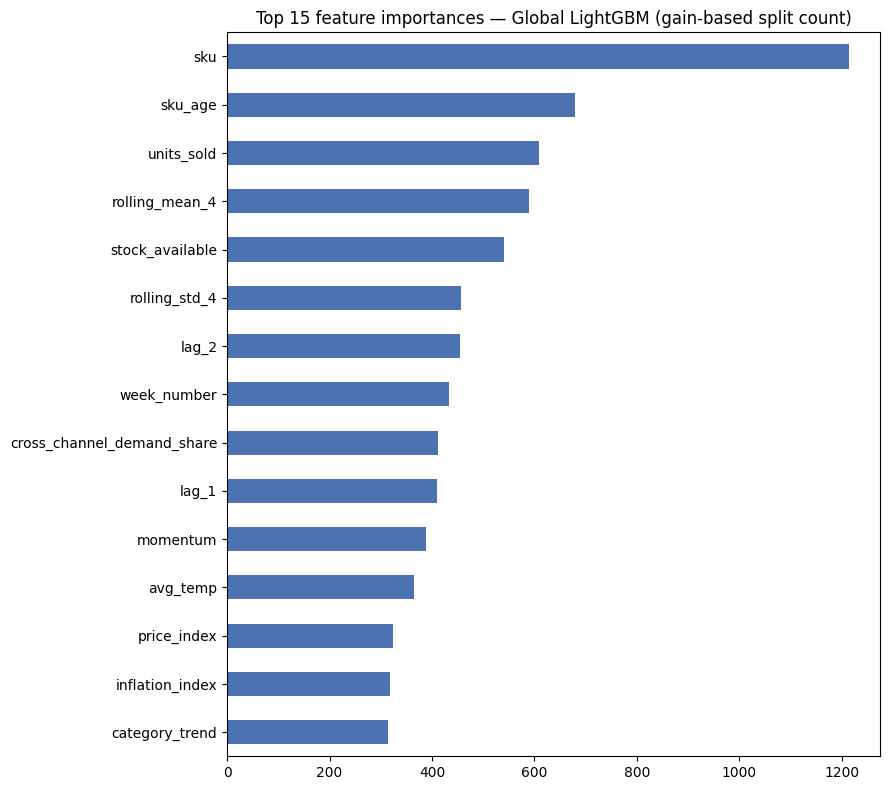

In [8]:
cv_all = dfc[~dfc.week.isin(final_test_weeks)]
full_model = fit_lgb(cv_all)

importance = pd.Series(full_model.feature_importances_, index=ALL_FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importance.head(15).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 feature importances — Global LightGBM (gain-based split count)')
plt.tight_layout()
plt.savefig('../reports/figures/phase7_feature_importance.png', dpi=120)
plt.show()


## 6. สรุป Phase 7

| โมเดล | CV WAPE | หมายเหตุ |
|---|---|---|
| Global pooled LightGBM | **ต่ำสุด (ดีที่สุด)** | ใช้ทุกฟีเจอร์ + pool ข้อมูลข้าม SKU |
| Local per-SKU LightGBM | สูงกว่า global | ข้อมูลต่อ SKU ไม่พอ โดยเฉพาะ SKU ใหม่ |
| Moving Avg (4w) baseline | สูงกว่า LightGBM ทั้งคู่ | เป็นเกณฑ์ขั้นต่ำจาก Phase 6 |
| ETS (top-5 series) | สูงสุด | ใช้แค่ประวัติของตัวเอง ไม่เห็นบริบท (ราคา/โปรโมชัน) |

**โมเดลที่เลือกใช้ต่อในโปรเจกต์: Global pooled LightGBM** — เป็น baseline สำหรับ Phase 10 (cold-start meta-learner), Phase 11 (feature ablation), และ Phase 13 (future holdout backtest)
